# 02. Accuracy, Bond Dimensions, and Sweeps

## Learning goals

- measure how accurately a QTT approximates its target function on the notebook grid
- inspect the bond-dimension profile of a one-dimensional QTT
- run controlled sweeps over `R` and `maxbonddim`
- use a small playground section to compare how different target functions behave under the same settings

## Before you run this notebook

From a terminal in the repository root, run:

```bash
julia --project=. -e 'using Pkg; Pkg.instantiate(); Pkg.build("Tensor4all"); Pkg.precompile()'
```

Then open the notebook in VS Code or Jupyter and select the Julia kernel that matches the version you used for setup. This notebook was last tested with Julia 1.12.

In [1]:
using Tensor4all
using CairoMakie
using LaTeXStrings

const QG = Tensor4all.QuanticsGrids
const QTCI = Tensor4all.QuanticsTCI
const TN = Tensor4all.TensorNetworks
const STT = Tensor4all.SimpleTT

Tensor4all.SimpleTT

## 1. Baseline example

We start with one function and one fixed parameter set. This baseline establishes the measurement pattern that the sweep sections will reuse.

The target function is `sin(30x)*cos(2x) + sin(50x)` — a more involved oscillatory function. We keep `R`, `value_type`, `tolerance`, `maxbonddim`, and `maxiter` visible in the code so it is clear what is being used.

In [2]:
target_function(x) = sin(30x)*cos(2x)+sin(50*x)

target_function (generic function with 1 method)

In [3]:
R = 7
npoints = 1 << R
grid = QG.DiscretizedGrid{1}(R, 0.0, 1.0; includeendpoint=false)
xvals = [QG.grididx_to_origcoord(grid, i) for i in 1:npoints]

value_type = Float64
tolerance = 1e-12
maxbonddim = 32
maxiter = 200

qtt, _, _ = QTCI.quanticscrossinterpolate(
    value_type,
    target_function,
    grid;
    tolerance=tolerance,
    maxbonddim=maxbonddim,
    maxiter=maxiter,
)

simple_tt = STT.TensorTrain(qtt.tci)
sites = [Tensor4all.Index(2; tags=["x", "bit=$i"]) for i in 1:length(simple_tt)]
indexed_tt = TN.TensorTrain(simple_tt, sites)
bond_dims = TN.linkdims(indexed_tt)

println("R = $R gives $npoints grid points on [0, 1).")
println("We interpolate $value_type values with tolerance = $tolerance, " *
        "maxbonddim = $maxbonddim, and maxiter = $maxiter.")
println("The tensor train uses $(length(simple_tt)) cores " *
        "and has bond dimensions $bond_dims.")


R = 7 gives 128 grid points on [0, 1).
We interpolate Float64 values with tolerance = 1.0e-12, maxbonddim = 32, and maxiter = 200.
The tensor train uses 7 cores and has bond dimensions [2, 4, 6, 6, 4, 2].


In [4]:
exact_values = target_function.(xvals)
qtt_values = [real(qtt(i)) for i in 1:npoints]
max_abs_error = maximum(abs.(exact_values .- qtt_values))

println("The maximum absolute error on this grid is $max_abs_error.")

The maximum absolute error on this grid is 6.661338147750939e-16.


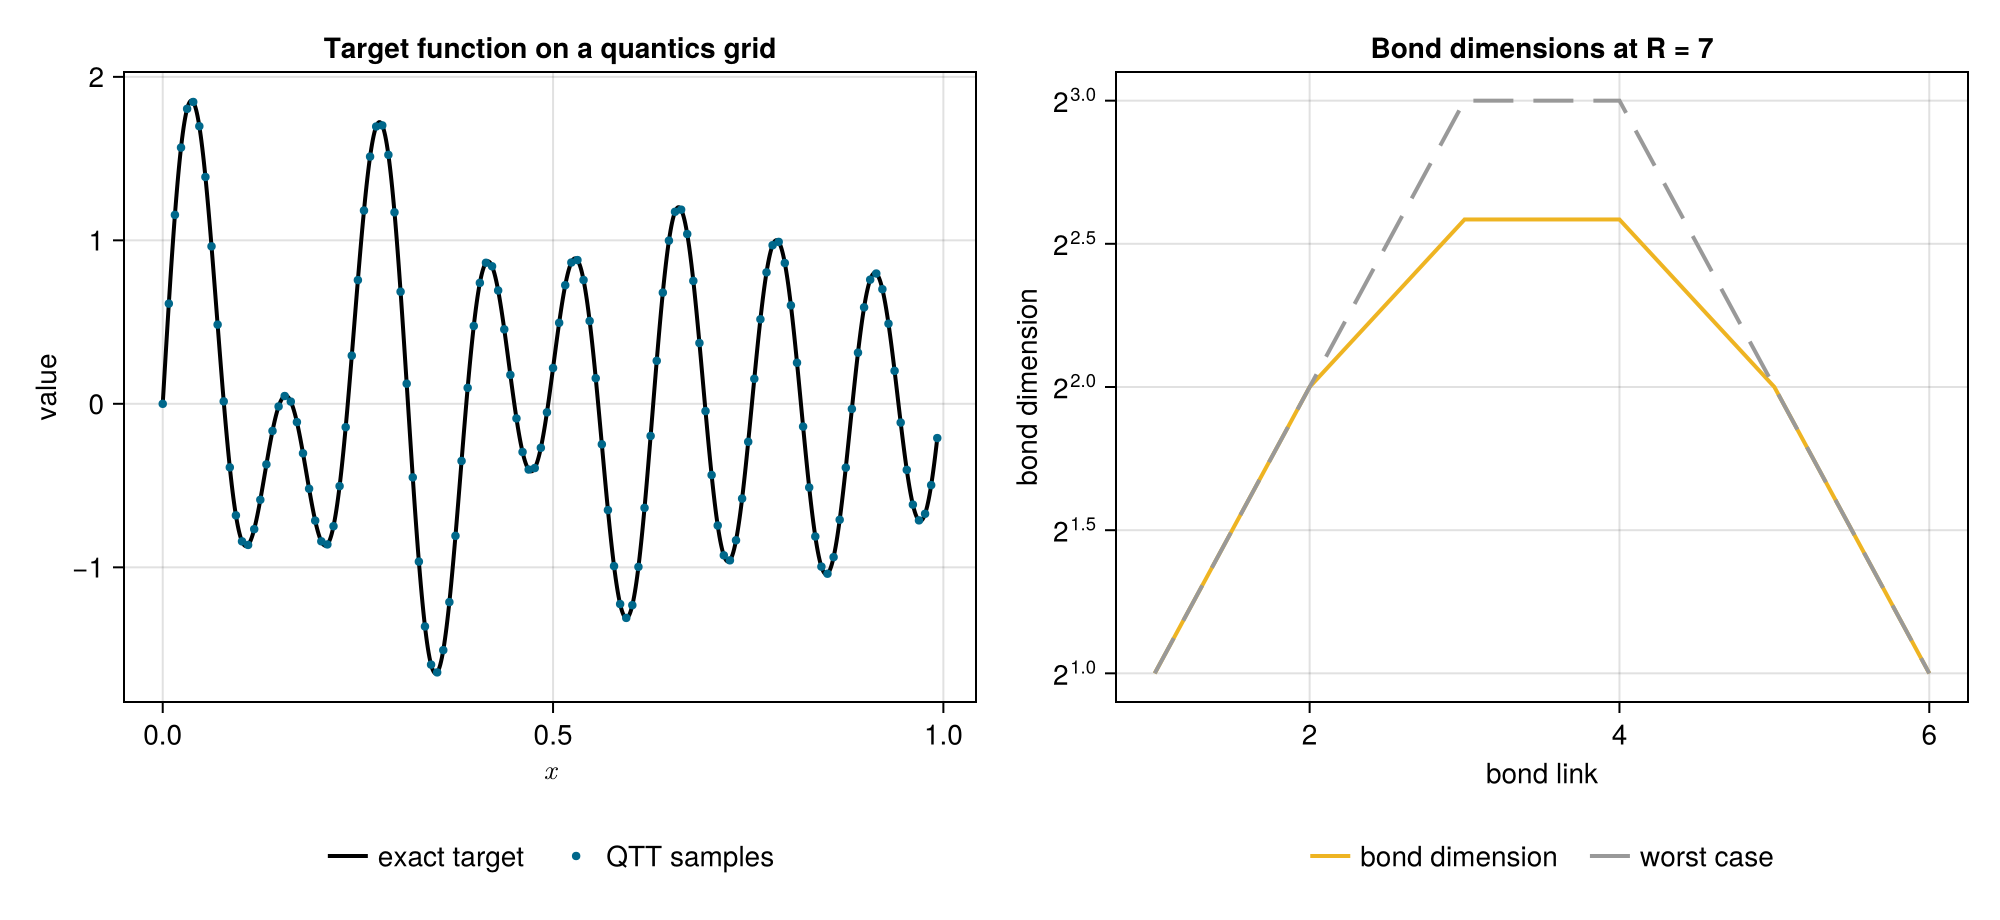

In [5]:
worst_case_bond_dims(num_bonds; base=2) =
    [base^min(k, num_bonds + 1 - k) for k in 1:num_bonds]

fig = Figure(size=(1000, 460))

ax1 = Axis(
    fig[1, 1],
    xlabel=L"x",
    ylabel="value",
    title="Target function on a quantics grid",
)
xs = range(first(xvals), last(xvals), length=1000)
lines!(ax1, xs, target_function.(xs);
    color=:black, linewidth=2, label="exact target")
scatter!(ax1, xvals, qtt_values;
    color=:deepskyblue4, markersize=6, label="QTT samples")
Legend(fig[2, 1], ax1, orientation=:horizontal, framevisible=false)

ax2 = Axis(
    fig[1, 2],
    xlabel="bond link",
    ylabel="bond dimension",
    title="Bond dimensions at R = $R",
    yscale=log2,
)
bond_index = 1:length(bond_dims)
lines!(ax2, bond_index, bond_dims;
    color=:goldenrod2, linewidth=2, label="bond dimension")
lines!(ax2, bond_index, worst_case_bond_dims(length(bond_dims));
    color=:gray60, linewidth=2,
    linestyle=Linestyle([0, 10, 15]),
    label="worst case")
Legend(fig[2, 2], ax2, orientation=:horizontal, framevisible=false)

fig

The left panel shows the exact function and the QTT samples. The right panel shows the bond-dimension profile.

For this target function, the bond dimensions are clearly below the worst-case envelope, but they are not as tiny as in the `cosh(x)` example from Notebook 01. That already tells us something useful: the QTT has found structure, but this oscillatory function still needs a moderate internal rank.

## 2. Sweep over R

Now we vary only `R` while keeping the target function, interval, `tolerance`, `maxbonddim`, and `maxiter` fixed.

`R` controls the bit depth and therefore the number of grid points (`npoints = 2^R`). A larger `R` gives a finer grid, but it does not automatically force the QTT to become structurally more complex. The question is: does more resolution help reduce the approximation error for this target?

### How the grids change with R

For a fixed value of $R$, the quantics grid has $2^R$ sample points. In this notebook we use `includeendpoint=false`, so the points lie on $[0, 1)$ at $$0, 1/2^R, 2/2^R, ..., (2^R - 1)/2^R.$$

These grids are nested: every point from a coarser grid also appears in the finer grids. You can think of this as building the grid by repeated halving. For example, the points from $R = 2$ also appear when $R = 3$, $R = 4$, and so on. This is why many markers in the sweep plot lie on top of each other.

If we instead use `includeendpoint=true`, the endpoint $1.0$ is included. Then the grid points become $$0, 1/(2^R - 1), 2/(2^R - 1), ..., 1.$$

That version is still evenly spaced, but it is no longer built by repeated halving in the same way. As a result, points from different values of $R$ do not line up nearly as often.


In [6]:
grid_demo_R_values = [2, 3]

for demo_R in grid_demo_R_values
    grid_without_endpoint = QG.DiscretizedGrid{1}(demo_R, 0.0, 1.0; includeendpoint=false)
    x_without_endpoint = [QG.grididx_to_origcoord(grid_without_endpoint, i) for i in 1:(1 << demo_R)]

    grid_with_endpoint = QG.DiscretizedGrid{1}(demo_R, 0.0, 1.0; includeendpoint=true)
    x_with_endpoint = [QG.grididx_to_origcoord(grid_with_endpoint, i) for i in 1:(1 << demo_R)]

    println("For R = $demo_R with includeendpoint=false, the grid points are $x_without_endpoint.")
    println("For R = $demo_R with includeendpoint=true, the grid points are $x_with_endpoint.")
    println()
end


For R = 2 with includeendpoint=false, the grid points are [0.0, 0.25, 0.5, 0.75].
For R = 2 with includeendpoint=true, the grid points are [0.0, 0.3333333333333333, 0.6666666666666666, 1.0].

For R = 3 with includeendpoint=false, the grid points are [0.0, 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875].
For R = 3 with includeendpoint=true, the grid points are [0.0, 0.14285714285714285, 0.2857142857142857, 0.42857142857142855, 0.5714285714285714, 0.7142857142857142, 0.8571428571428571, 1.0].



In [7]:
sweep_R_values = [2, 3, 4, 5, 6, 7]
sweep_R_max_abs_errors = Float64[]
sweep_R_all_bond_dims = Vector{Vector{Int}}()
sweep_R_sample_xvals = Vector{Vector{Float64}}()
sweep_R_sample_values = Vector{Vector{Float64}}()

for sweep_R in sweep_R_values
    sweep_npoints = 1 << sweep_R
    sweep_grid = QG.DiscretizedGrid{1}(sweep_R, 0.0, 1.0; includeendpoint=false)

    sweep_qtt, _, _ = QTCI.quanticscrossinterpolate(
        value_type,
        target_function,
        sweep_grid;
        tolerance=tolerance,
        maxbonddim=maxbonddim,
        maxiter=maxiter,
    )

    sweep_simple_tt = STT.TensorTrain(sweep_qtt.tci)
    sweep_sites = [Tensor4all.Index(2; tags=["x", "bit=$i"])
        for i in 1:length(sweep_simple_tt)]
    sweep_indexed_tt = TN.TensorTrain(sweep_simple_tt, sweep_sites)
    sweep_bond_dims = TN.linkdims(sweep_indexed_tt)

    sweep_xvals = [QG.grididx_to_origcoord(sweep_grid, i) for i in 1:sweep_npoints]
    sweep_exact = target_function.(sweep_xvals)
    sweep_values = [real(sweep_qtt(i)) for i in 1:sweep_npoints]
    sweep_max_abs_error = maximum(abs.(sweep_exact .- sweep_values))
    sweep_max_bond_dim = maximum(sweep_bond_dims)

    push!(sweep_R_max_abs_errors, sweep_max_abs_error)
    push!(sweep_R_all_bond_dims, sweep_bond_dims)
    push!(sweep_R_sample_xvals, sweep_xvals)
    push!(sweep_R_sample_values, sweep_values)

    println("For R = $sweep_R, the maximum absolute error is $sweep_max_abs_error and the maximum bond dimension is $sweep_max_bond_dim.")
end


For R = 2, the maximum absolute error is 0.0 and the maximum bond dimension is 2.
For R = 3, the maximum absolute error is 3.75914882810925e-17 and the maximum bond dimension is 2.
For R = 4, the maximum absolute error is 5.551115123125783e-17 and the maximum bond dimension is 4.
For R = 5, the maximum absolute error is 2.220446049250313e-16 and the maximum bond dimension is 4.
For R = 6, the maximum absolute error is 1.2212453270876722e-15 and the maximum bond dimension is 6.
For R = 7, the maximum absolute error is 6.661338147750939e-16 and the maximum bond dimension is 6.


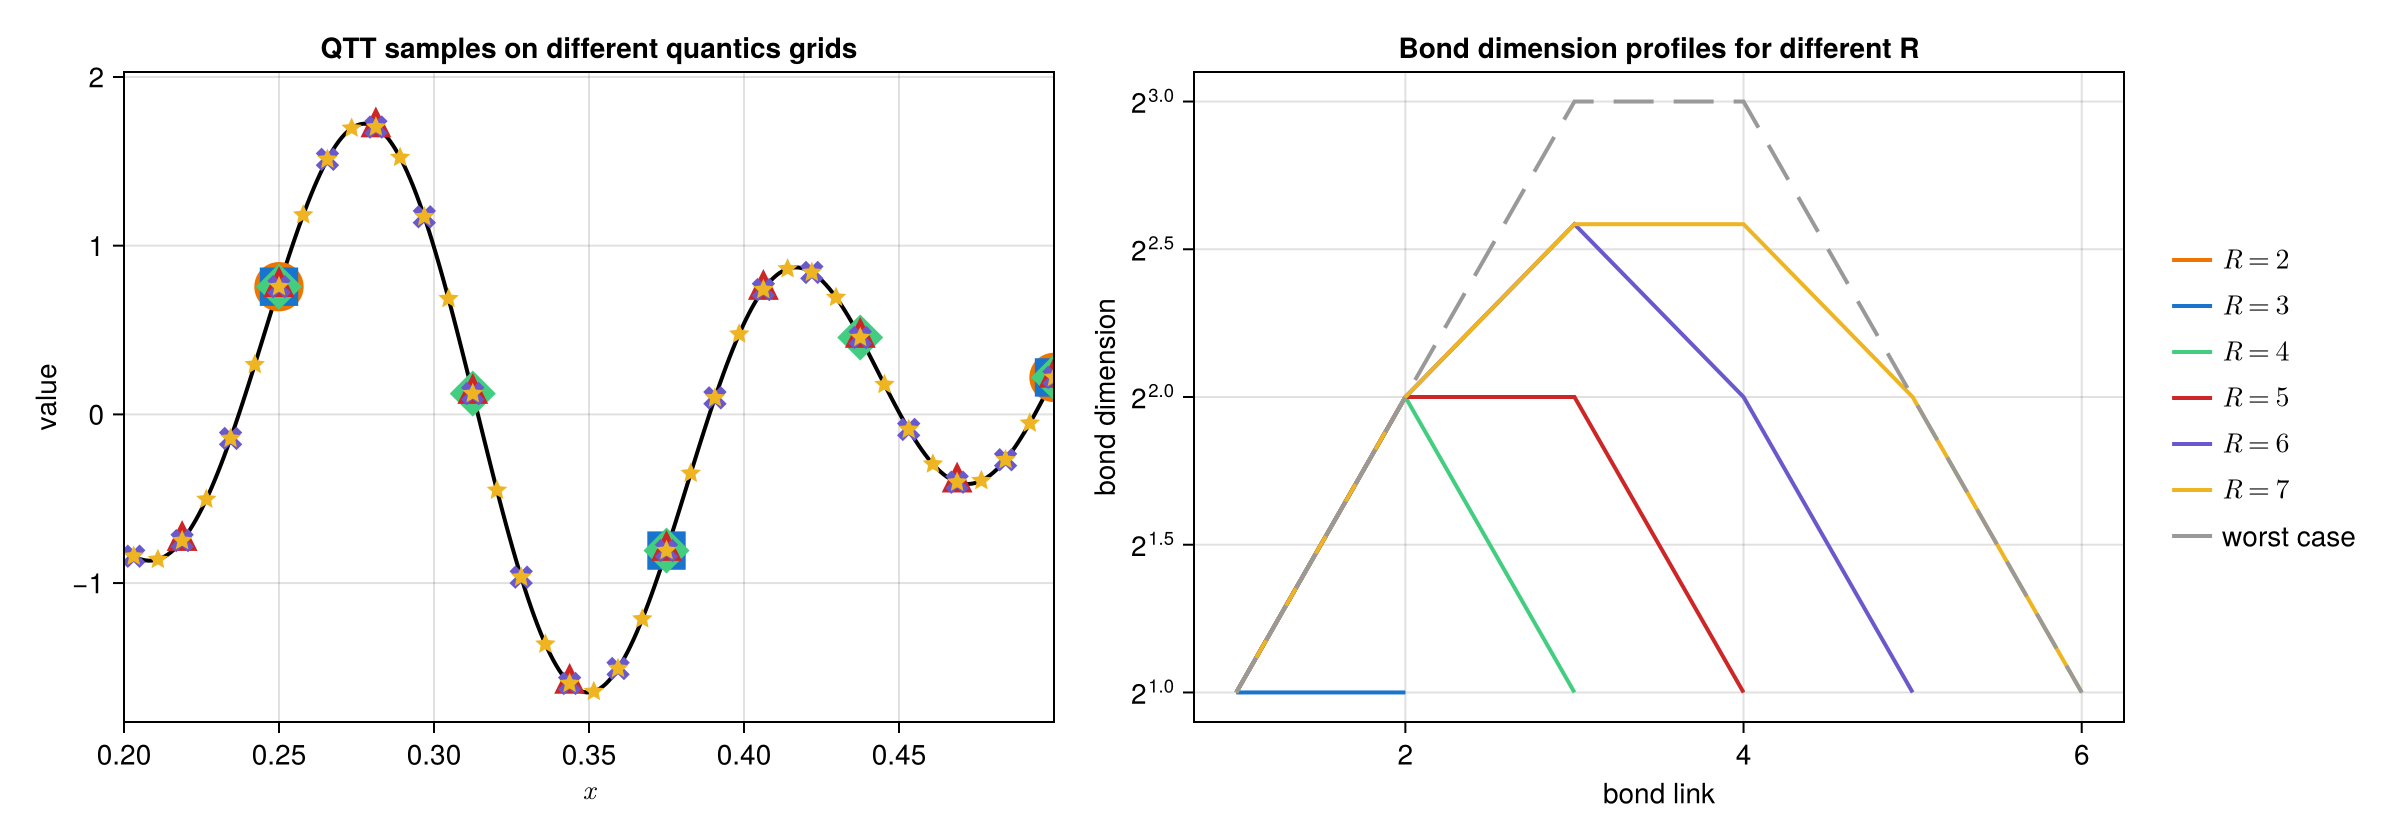

In [8]:
fig_R = Figure(size=(1200, 420))

axR1 = Axis(
    fig_R[1, 1],
    xlabel=L"x",
    ylabel="value",
    title="QTT samples on different quantics grids"
)
xs_dense = range(0, 1, length=1000)
lines!(axR1, xs_dense, target_function.(xs_dense);
    color=:black, linewidth=2)

palette = [:darkorange2, :dodgerblue3, :seagreen3,  :firebrick3, :slateblue3, :goldenrod2, :mediumorchid3, :darkgreen]
marker_cycle = [:circle, :rect, :diamond, :utriangle, :xcross, :star5, :dtriangle, :hexagon]
palette = [palette[mod1(i, length(palette))] for i in eachindex(sweep_R_values)]
markers = [marker_cycle[mod1(i, length(marker_cycle))] for i in eachindex(sweep_R_values)]
marker_sizes = collect(range(35, 12, length=length(sweep_R_values)))

for (i, sweep_R) in enumerate(sweep_R_values)
    scatter!(axR1, sweep_R_sample_xvals[i], sweep_R_sample_values[i];
        color=palette[i],
        marker=markers[i],
        markersize=marker_sizes[i])
end
xlims!(axR1, 0.2, 0.5)

axR2 = Axis(
    fig_R[1, 2],
    xlabel="bond link",
    ylabel="bond dimension",
    title="Bond dimension profiles for different R",
    yscale=log2,
)
for (i, sweep_R) in enumerate(sweep_R_values)
    bond_profile = sweep_R_all_bond_dims[i]
    bond_idx = 1:length(bond_profile)
    lines!(axR2, bond_idx, bond_profile;
        color=palette[i], linewidth=2, label=L"R = %$sweep_R")
end
worst = worst_case_bond_dims(length(sweep_R_all_bond_dims[end]))
lines!(axR2, 1:length(worst), worst;
    color=:gray60, linewidth=2,
    linestyle=Linestyle([0, 10, 15]),
    label="worst case")
Legend(fig_R[1, 3], axR2, framevisible=false)

fig_R

The left panel now shows the exact function together with the QTT sample points for several values of `R`. This makes the role of the quantics grid much more visible: as `R` increases, the samples become denser and trace the oscillations more faithfully. The right panel shows the corresponding bond-dimension profiles.

In this notebook we use `includeendpoint=false`, so the grids are nested on `[0, 1)`: every sample point from a smaller value of `R` reappears at larger values of `R`. This is why many markers lie on top of each other at locations such as `0.5`, `0.25`, and `0.75`.

For this example, the most dramatic change is not in the measured grid error but in the sampling density and the internal rank structure. The peak bond dimension grows up to `6` and then stabilizes, while the profiles continue to get longer as more quantics bits are added.


## 3. Sweep over maxbonddim

Now we vary only `maxbonddim` while keeping everything else fixed.

`maxbonddim` is the artificial cap on how much internal room the QTT may use. We keep `tolerance` visible as a fixed accuracy target, but the main question in this section is simpler: how much rank does this function actually need before the approximation stops improving?

In [9]:
sweep_maxbonddim_values = [1, 2, 4, 8, 16, 32]
sweep_mbd_max_abs_errors = Float64[]
sweep_mbd_max_bond_dims = Int[]

for sweep_maxbonddim in sweep_maxbonddim_values
    sweep_qtt, _, _ = QTCI.quanticscrossinterpolate(
        value_type,
        target_function,
        grid;
        tolerance=tolerance,
        maxbonddim=sweep_maxbonddim,
        maxiter=maxiter,
    )

    sweep_simple_tt = STT.TensorTrain(sweep_qtt.tci)
    sweep_sites = [Tensor4all.Index(2; tags=["x", "bit=$i"])
        for i in 1:length(sweep_simple_tt)]
    sweep_indexed_tt = TN.TensorTrain(sweep_simple_tt, sweep_sites)
    sweep_bond_dims = TN.linkdims(sweep_indexed_tt)

    sweep_values = [real(sweep_qtt(i)) for i in 1:npoints]
    sweep_max_abs_error = maximum(abs.(exact_values .- sweep_values))
    sweep_max_bond_dim = maximum(sweep_bond_dims)

    push!(sweep_mbd_max_abs_errors, sweep_max_abs_error)
    push!(sweep_mbd_max_bond_dims, sweep_max_bond_dim)

    println("For maxbonddim = $sweep_maxbonddim, the maximum absolute error is " *
            "$sweep_max_abs_error and the maximum bond dimension " *
            "is $sweep_max_bond_dim.")
end

For maxbonddim = 1, the maximum absolute error is 1.31631290238826 and the maximum bond dimension is 1.
For maxbonddim = 2, the maximum absolute error is 0.9598376932839741 and the maximum bond dimension is 2.
For maxbonddim = 4, the maximum absolute error is 0.02963380011287564 and the maximum bond dimension is 4.
For maxbonddim = 8, the maximum absolute error is 6.661338147750939e-16 and the maximum bond dimension is 6.
For maxbonddim = 16, the maximum absolute error is 6.661338147750939e-16 and the maximum bond dimension is 6.
For maxbonddim = 32, the maximum absolute error is 6.661338147750939e-16 and the maximum bond dimension is 6.


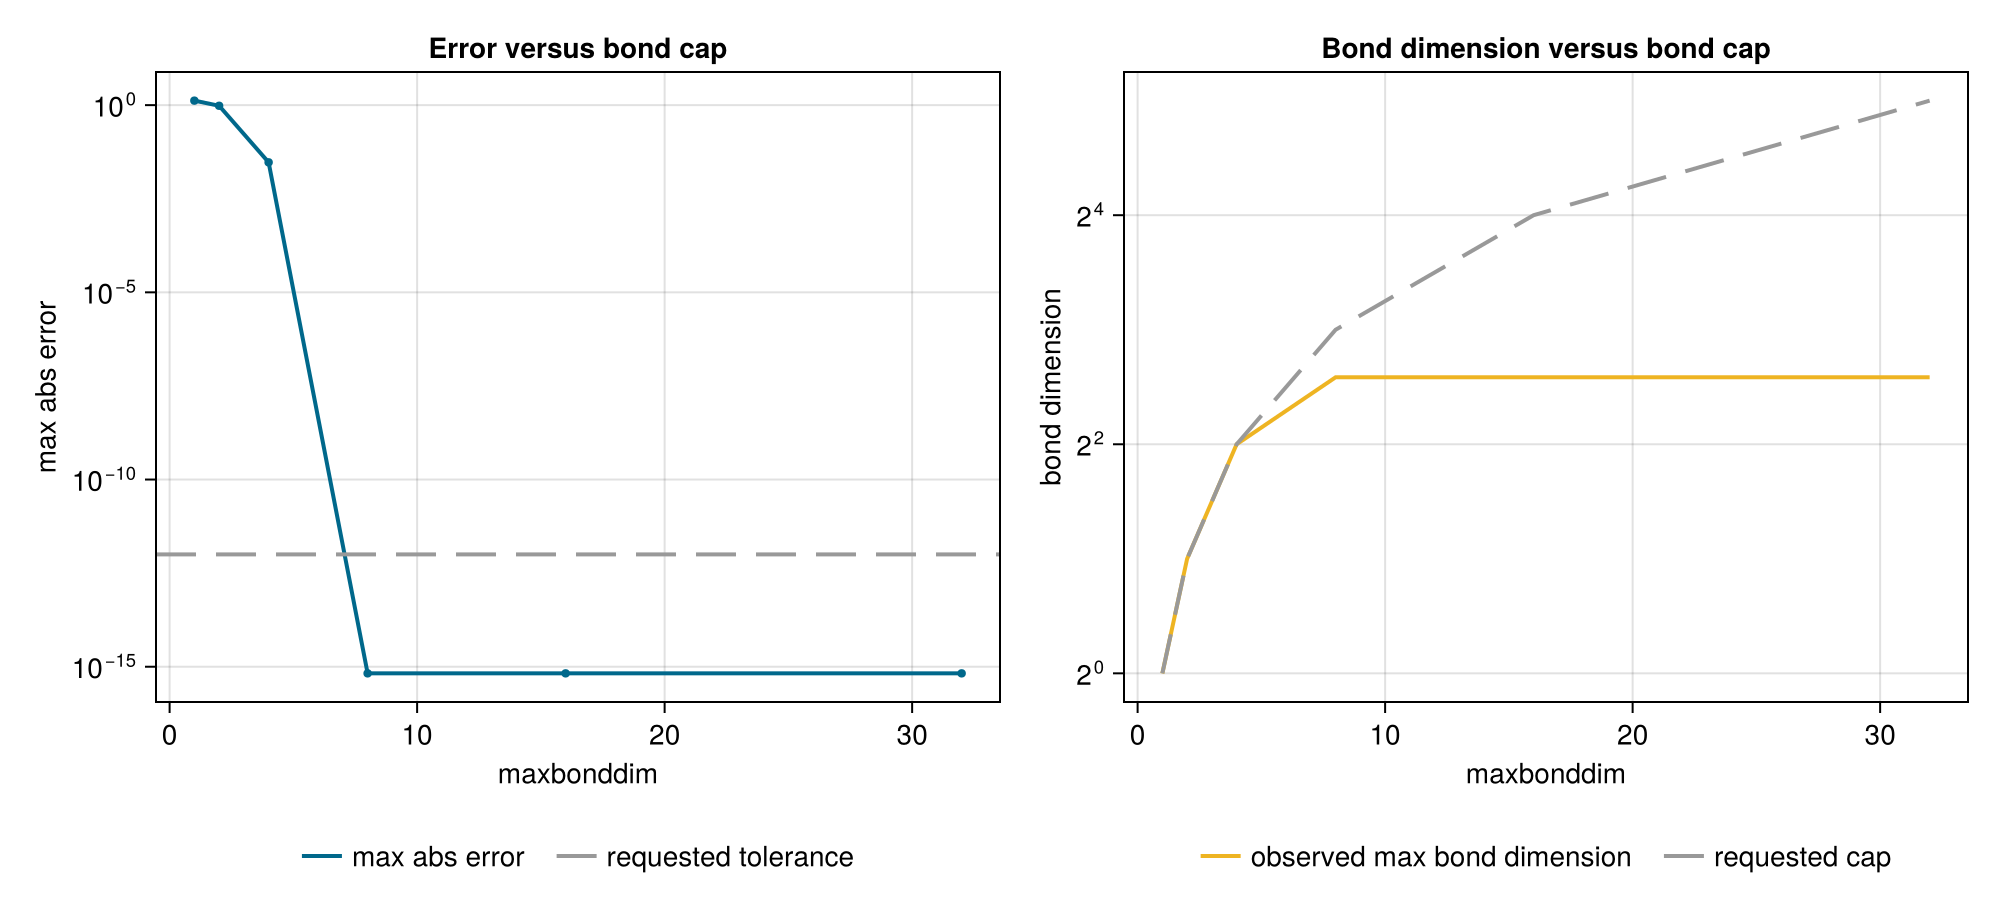

In [10]:
fig_mbd = Figure(size=(1000, 460))

axmbd1 = Axis(
    fig_mbd[1, 1],
    xlabel="maxbonddim",
    ylabel="max abs error",
    title="Error versus bond cap",
    yscale=log10,
)
lines!(axmbd1, sweep_maxbonddim_values, sweep_mbd_max_abs_errors;
    color=:deepskyblue4, linewidth=2, label="max abs error")
scatter!(axmbd1, sweep_maxbonddim_values, sweep_mbd_max_abs_errors;
    color=:deepskyblue4, markersize=6)
hlines!(axmbd1, tolerance;
    color=:gray60, linewidth=2,
    linestyle=Linestyle([0, 10, 15]),
    label="requested tolerance")
Legend(fig_mbd[2, 1], axmbd1, orientation=:horizontal, framevisible=false)

axmbd2 = Axis(
    fig_mbd[1, 2],
    xlabel="maxbonddim",
    ylabel="bond dimension",
    title="Bond dimension versus bond cap",
    yscale=log2,
)
lines!(axmbd2, sweep_maxbonddim_values, sweep_mbd_max_bond_dims;
    color=:goldenrod2, linewidth=2, label="observed max bond dimension")
lines!(axmbd2, sweep_maxbonddim_values, sweep_maxbonddim_values;
    color=:gray60, linewidth=2,
    linestyle=Linestyle([0, 10, 15]),
    label="requested cap")
Legend(fig_mbd[2, 2], axmbd2, orientation=:horizontal, framevisible=false)

fig_mbd

A cap of `1` is far too small — the QTT cannot represent the function accurately. At `2` and `4` the cap is still too tight: the algorithm is forced to stop early and the error remains large. Once the cap reaches `8`, the observed bond dimension reaches the natural rank of `6` and the error drops to the tolerance level. Larger caps do not help further because the representation has already stabilized.

This is the second key distinction in this notebook: `maxbonddim` is an artificial limit. It can prevent the algorithm from finding a good approximation, but raising it beyond the natural rank of the function does not improve accuracy.

## 4. Playground: compare target functions

So far we have kept the workflow fixed and changed only the grid resolution `R` or the rank cap `maxbonddim`. A natural next step is to keep those settings fixed and change the function instead.

This section is meant as a small playground. We compare the oscillatory baseline function with `cosh(x)`, whose QTT representation stays especially compact. If you want to explore, replace either function in the next cell and rerun the next two cells.

In [11]:
playground_functions = [x -> sin(30x)*cos(2x)+sin(50*x), x -> cosh(x)]
playground_names = ["sin(30x)*cos(2x) + sin(50x)", "cosh(x)"]

playground_bond_dims_list = Vector{Vector{Int}}()
playground_max_abs_errors = Float64[]

for (f, fname) in zip(playground_functions, playground_names)
    playground_qtt, _, _ = QTCI.quanticscrossinterpolate(
        value_type,
        f,
        grid;
        tolerance=tolerance,
        maxbonddim=maxbonddim,
        maxiter=maxiter,
    )

    playground_simple_tt = STT.TensorTrain(playground_qtt.tci)
    playground_sites = [Tensor4all.Index(2; tags=["x", "bit=$i"])
        for i in 1:length(playground_simple_tt)]
    playground_indexed_tt = TN.TensorTrain(playground_simple_tt, playground_sites)
    playground_bond_dims = TN.linkdims(playground_indexed_tt)

    playground_values = [real(playground_qtt(i)) for i in 1:npoints]
    playground_exact = f.(xvals)
    playground_max_abs_error = maximum(abs.(playground_exact .- playground_values))

    push!(playground_bond_dims_list, playground_bond_dims)
    push!(playground_max_abs_errors, playground_max_abs_error)

    println("For $fname, the maximum absolute error is $playground_max_abs_error and the bond dimensions are $playground_bond_dims.")
end

For sin(30x)*cos(2x) + sin(50x), the maximum absolute error is 6.661338147750939e-16 and the bond dimensions are [2, 4, 6, 6, 4, 2].
For cosh(x), the maximum absolute error is 4.440892098500626e-16 and the bond dimensions are [2, 2, 2, 2, 2, 2].


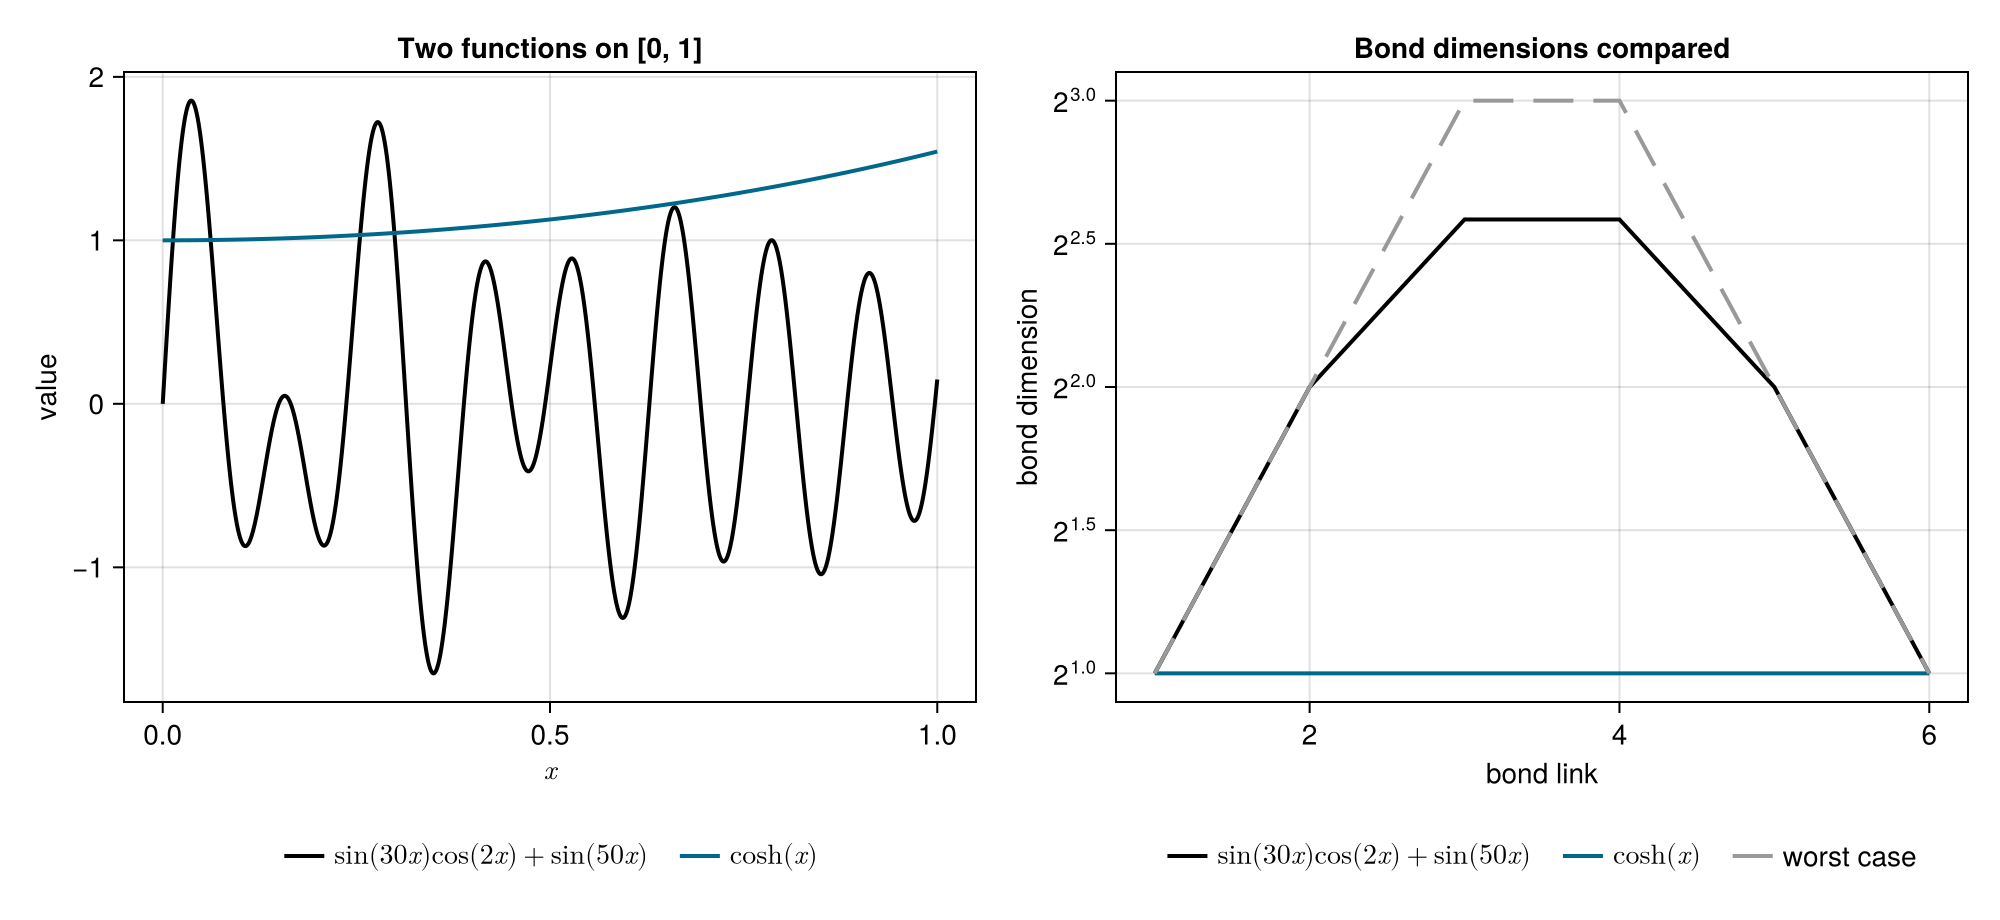

In [12]:
fig_comp = Figure(size=(1000, 460))

playground_labels = [L"\sin(30x)\cos(2x) + \sin(50x)", L"\cosh(x)"]

axc1 = Axis(
    fig_comp[1, 1],
    xlabel=L"x",
    ylabel="value",
    title="Two functions on [0, 1]",
)
xs_comp = range(0, 1, length=1000)
lines!(axc1, xs_comp, playground_functions[1].(xs_comp);
    color=:black, linewidth=2, label=playground_labels[1])
lines!(axc1, xs_comp, playground_functions[2].(xs_comp);
    color=:deepskyblue4, linewidth=2, label=playground_labels[2])
Legend(fig_comp[2, 1], axc1, orientation=:horizontal, framevisible=false)

axc2 = Axis(
    fig_comp[1, 2],
    xlabel="bond link",
    ylabel="bond dimension",
    title="Bond dimensions compared",
    yscale=log2,
)
bond_index_1 = 1:length(playground_bond_dims_list[1])
lines!(axc2, bond_index_1, playground_bond_dims_list[1];
    color=:black, linewidth=2, label=playground_labels[1])
bond_index_2 = 1:length(playground_bond_dims_list[2])
lines!(axc2, bond_index_2, playground_bond_dims_list[2];
    color=:deepskyblue4, linewidth=2, label=playground_labels[2])
worst_case_profile = worst_case_bond_dims(length(playground_bond_dims_list[1]))
worst_case_index = 1:length(worst_case_profile)
lines!(axc2, worst_case_index, worst_case_profile;
    color=:gray60, linewidth=2,
    linestyle=Linestyle([0, 10, 15]),
    label="worst case")
Legend(fig_comp[2, 2], axc2, orientation=:horizontal, framevisible=false)

fig_comp

Both functions achieve low error under the same settings, but their bond-dimension profiles are clearly different. The oscillatory baseline function needs a noticeably larger internal rank, while `cosh(x)` stays compact with bond dimension `2` throughout.

That is the main lesson of this playground: the same QTT pipeline can behave very differently for different functions. If you replace one of the functions above and rerun these cells, the error and bond-dimension profile may change in ways that are worth comparing.

## What to notice

- `R` controls the grid resolution and the length of the quantics representation. In this example the measured grid error stays tiny, while the bond-dimension profile still changes noticeably.
- `maxbonddim` is an artificial cap. Setting it too low prevents the algorithm from finding an accurate approximation. Setting it above the natural rank does not help further.
- In this notebook we kept `tolerance` fixed as a background accuracy target and focused on the two more instructive levers for this example: resolution and rank cap.
- The same QTT workflow can behave very differently for different target functions, so it is worth comparing both error and bond dimensions.
- Different functions can have very different bond-dimension profiles under the same parameter settings.

## API recap

- `Tensor4all.QuanticsGrids.DiscretizedGrid{1}`
- `Tensor4all.QuanticsGrids.grididx_to_origcoord`
- `Tensor4all.QuanticsTCI.quanticscrossinterpolate`
- `Tensor4all.SimpleTT.TensorTrain`
- `Tensor4all.TensorNetworks.TensorTrain`
- `Tensor4all.TensorNetworks.linkdims`
- `Tensor4all.Index`